# Scene infrastructure near the twenty largest FUAs

## tl;dr

The OpenStreetMap capture identifies **1,702
classified infrastructure elements** around the twenty study-city centres.
London has **408 distinct mapped music places**
within 15 km. Across the nineteen FUAs with a top-1,000 scene-depth result, the
rank correlation between the raw mapped-place count and effective-band count
is **0.72**. The correlation
between infrastructure per capita and the follower output quotient is only
**0.13**. These are current
documentation patterns, not evidence that infrastructure caused band output.

## Context and methods

The infrastructure branch counts OpenStreetMap nodes and ways tagged as music
venues, nightclubs, arts centres, music shops or audio studios within 15 km of
each study-city centre. Universities are counted separately as context. The
result is joined to the effective-band count and follower output quotient from
experiment 17.

### Assumptions

The 15 km circles are reproducible comparison windows, not OECD FUA boundaries.
OpenStreetMap is a live, volunteer-maintained inventory: missing tags mean
"not observed here," not "does not exist." Current places cannot explain bands
formed decades earlier without historical infrastructure data.

Source documentation: [Overpass QL](https://wiki.openstreetmap.org/wiki/Overpass_API/Overpass_QL)
and [Nominatim usage policy](https://operations.osmfoundation.org/policies/nominatim/).

## Data

Parse the checkpointed OpenStreetMap/Overpass capture.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src/python_uk_bands").exists():
    ROOT = next(
        parent for parent in Path.cwd().resolve().parents
        if (parent / "src/python_uk_bands").exists()
    )
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ARTIFACT_DIR = ROOT / "artifacts/experiments/scene_infrastructure/20260725"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
from python_uk_bands.review_extension_experiments import (
    build_scene_infrastructure,
    plot_infrastructure_counts,
    plot_infrastructure_vs_depth,
)

OSM_PATH = ROOT / "data/raw/openstreetmap/music_infrastructure_20260725.json"
place_audit, city_infrastructure, coverage = build_scene_infrastructure(
    ROOT, osm_path=OSM_PATH
)

assert len(city_infrastructure) == 20
assert not place_audit.duplicated(
    ["study_city_label", "element_key", "category"]
).any()
assert city_infrastructure["music_place_count"].ge(0).all()
assert city_infrastructure["music_places_per_million"].ge(0).all()

place_audit.to_csv(ARTIFACT_DIR / "osm_place_audit.csv", index=False)
city_infrastructure.to_csv(ARTIFACT_DIR / "city_infrastructure_summary.csv", index=False)
(ARTIFACT_DIR / "coverage_summary.json").write_text(
    json.dumps(coverage, indent=2, sort_keys=True) + "\n"
)

display(Markdown(
    f"**{coverage['classified_elements']:,} classified elements · "
    f"{coverage['named_row_share']:.1%} named rows · "
    f"{coverage['cities_with_scene_depth']}/20 cities with scene-depth results**"
))

**1,702 classified elements · 96.8% named rows · 19/20 cities with scene-depth results**

## Results

### 1. What infrastructure is currently mapped near each city centre?

study_city_label,music_place_count,music_places_per_million,Music venue,Nightclub,Arts centre,Music shop,Audio studio,University
London,408,32.2,9,142,122,97,38,145
Birmingham,157,48.3,1,109,26,16,5,31
Bristol,74,72.2,1,29,19,23,2,22
Edinburgh,74,79.4,3,19,26,19,7,23
Glasgow,73,38.5,3,25,22,16,7,7
Manchester,72,20.0,2,26,16,24,4,14
Leeds,54,17.6,2,25,14,11,2,18
Sheffield,53,43.5,4,21,18,8,2,7
Liverpool,50,31.3,0,36,6,7,1,9
Newcastle,48,39.3,3,17,17,10,1,9


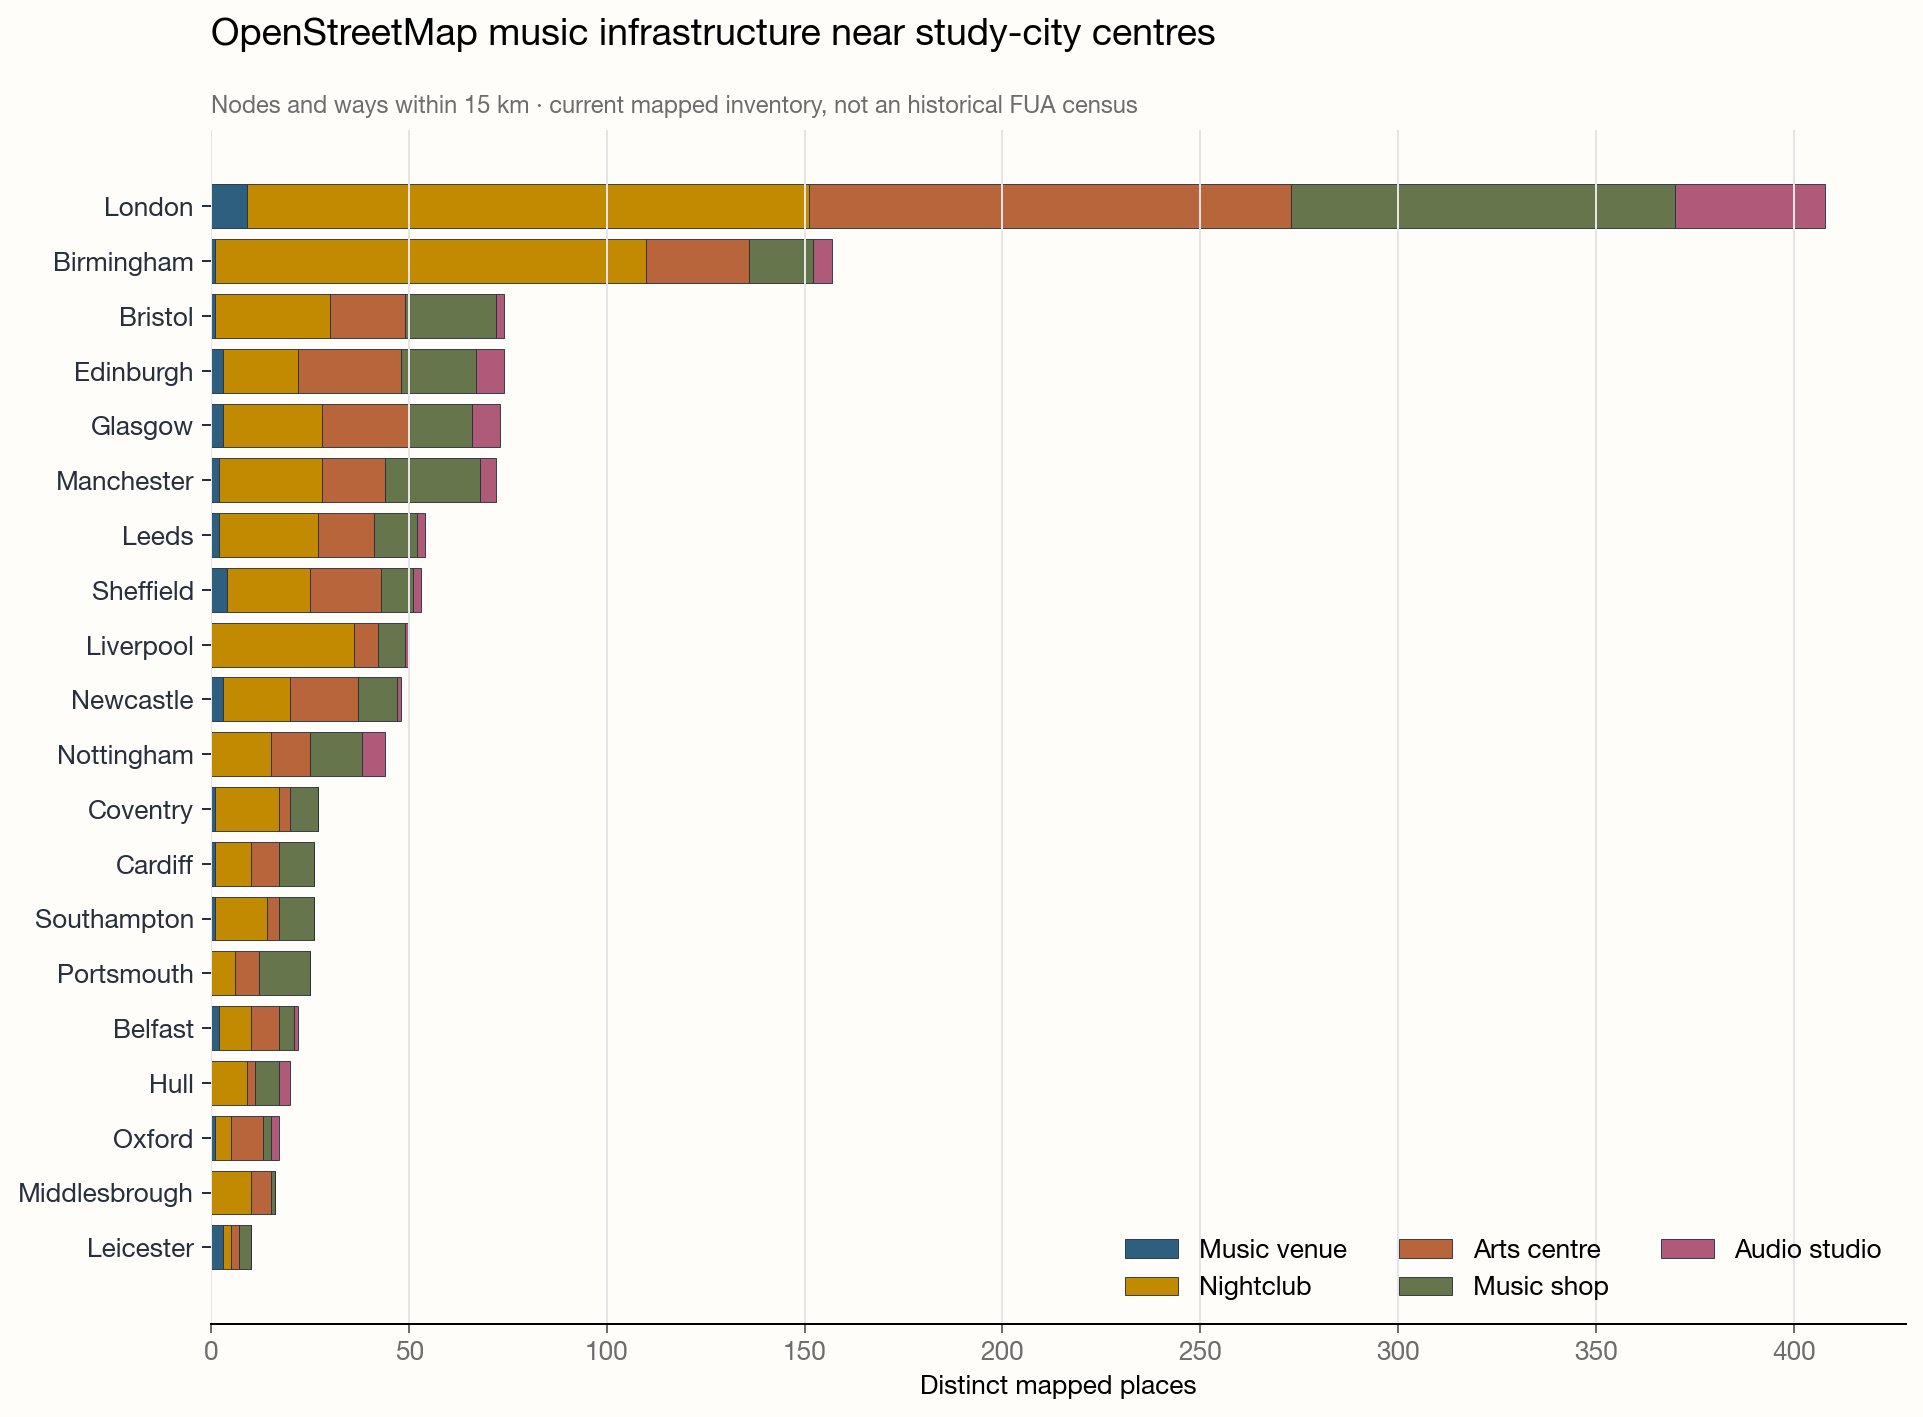

In [3]:
display(city_infrastructure[[
    "study_city_label", "music_place_count", "music_places_per_million",
    "Music venue", "Nightclub", "Arts centre", "Music shop", "Audio studio",
    "University",
]].style.hide(axis="index").format({"music_places_per_million": "{:.1f}"}))

count_path = plot_infrastructure_counts(
    city_infrastructure,
    output_path=ARTIFACT_DIR / "chart_01_infrastructure_counts.png",
)
display(Image(filename=str(count_path)))

### 2. Does mapped infrastructure track selected-scene breadth?

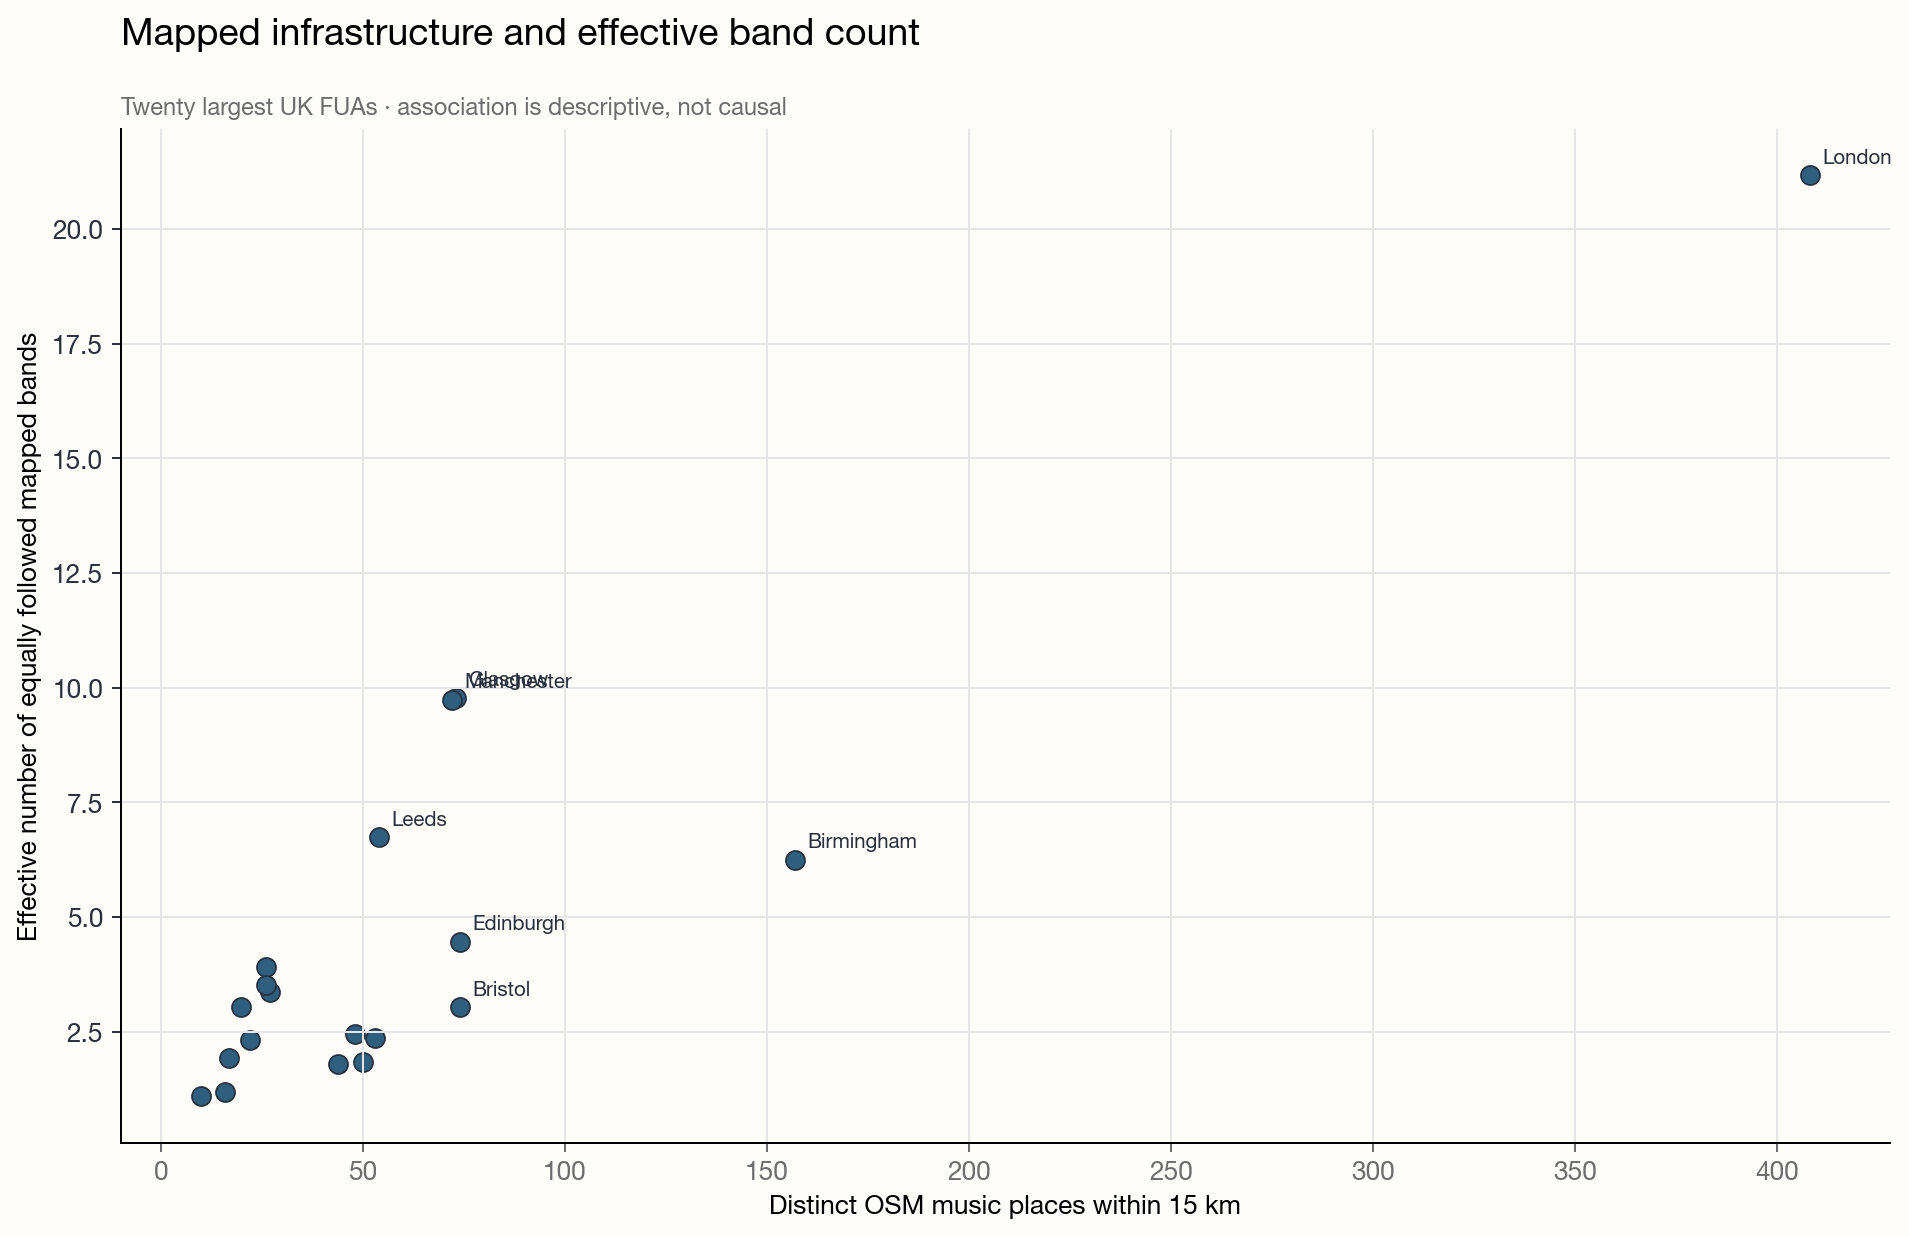

comparison,Spearman rank correlation
raw music-place count vs effective-band count,0.71
music places per million vs follower output quotient,0.07


In [4]:
relationship_path = plot_infrastructure_vs_depth(
    city_infrastructure,
    output_path=ARTIFACT_DIR / "chart_02_infrastructure_vs_depth.png",
)
display(Image(filename=str(relationship_path)))

display(pd.DataFrame({
    "comparison": [
        "raw music-place count vs effective-band count",
        "music places per million vs follower output quotient",
    ],
    "Spearman rank correlation": [
        coverage["rank_correlation_count_vs_depth"],
        coverage["rank_correlation_density_vs_output"],
    ],
}).style.hide(axis="index").format({"Spearman rank correlation": "{:.2f}"}))

## Takeaways

- Larger and broader music cities tend to have more currently mapped places,
  but city size and mapping intensity are obvious alternative explanations.
- Per-capita infrastructure does not track the follower output quotient in
  this twenty-city comparison.
- Dedicated `music_venue` tagging is sparse; nightclubs, arts centres and
  shops account for much of the observed inventory.
- Historical directories, venue opening dates, labels, rehearsal rooms, rents
  and funding would be needed for an explanatory infrastructure study.